In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/3
    print("準備完了！このまま下のセルを実行できます。")

# 3.1 線形基底関数モデル (Linear Basis Function Models)

本ノートブックでは、入力変数の非線形変換（基底関数）の線形結合として定義される**線形基底関数モデル**を徹底的に解説・実装・可視化します。
最尤推定による最小二乗解の導出、直交射影としての幾何学的解釈、逐次学習アルゴリズム（LMS法）、正則化（Ridge / Lasso）とスパース性の幾何学、そして複数出力への拡張を網羅します。

## 3.1.0 線形基底関数モデルの定式化

回帰の最も単純な形式は入力変数の線形結合 $y(\mathbf{x}, \mathbf{w}) = w_0 + w_1 x_1 + \dots + w_D x_D$ ですが、入力変数 $\mathbf{x}$ の固定された非線形変換 $\phi_j(\mathbf{x})$ （**基底関数**）を用いることで、パラメータ $\mathbf{w}$ に関する線形性を保ちながら極めて柔軟な非線形関数を表現できます。

$$ y(\mathbf{x}, \mathbf{w}) = w_0 + \sum_{j=1}^{M-1} w_j \phi_j(\mathbf{x}) = \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}) $$

ここで $\phi_0(\mathbf{x}) = 1$ と定義すると、バイアスパラメータ $w_0$ を含めて簡潔な内積形式で表現できます。

### 代表的な基底関数
1. **多項式基底 (Polynomial)**: $\phi_j(x) = x^j$ （大域的な関数であり、入力の一部の変化が全領域に影響する）
2. **ガウス基底 (Gaussian / RBF)**: $\phi_j(x) = \exp\left( -\frac{(x - \mu_j)^2}{2s^2} \right)$ （局所的な基底関数であり、中心 $\mu_j$ の近傍でのみ有意な値を持つ）
3. **シグモイド基底 (Sigmoidal)**: $\phi_j(x) = \sigma\left( \frac{x - \mu_j}{s} \right) = \frac{1}{1 + \exp(-(x - \mu_j)/s)}$ （ステップ関数の滑らかな近似）
4. **双曲線正接基底 (tanh)**: $\tanh(a) = 2\sigma(2a) - 1$ より、シグモイド基底と線形変換で等価です。

Plot saved to: result/fig3_1_basis_functions.png


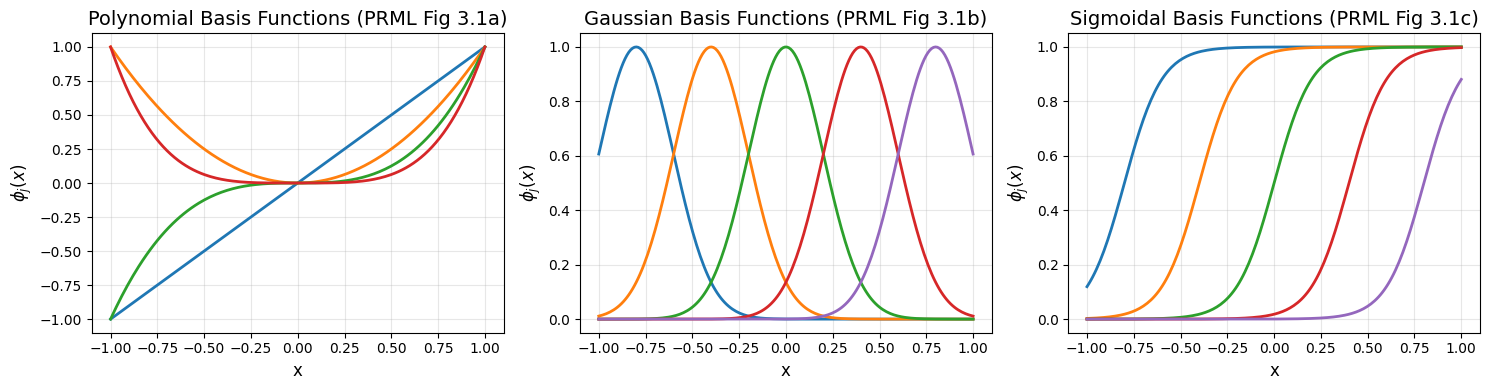

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.regression_utils import PolynomialBasis, GaussianBasis, SigmoidalBasis
setup_style()

x = np.linspace(-1, 1, 200)
centers = np.linspace(-0.8, 0.8, 5)

poly = PolynomialBasis(degree=4)
gauss = GaussianBasis(centers=centers, scale=0.2)
sigm = SigmoidalBasis(centers=centers, scale=0.1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Polynomial
axes[0].plot(x, poly(x)[:, 1:], lw=2)
axes[0].set_title('Polynomial Basis Functions (PRML Fig 3.1a)')
axes[0].set_xlabel('x')
axes[0].set_ylabel(r'$\phi_j(x)$')
axes[0].grid(True, alpha=0.3)

# 2. Gaussian
axes[1].plot(x, gauss(x)[:, 1:], lw=2)
axes[1].set_title('Gaussian Basis Functions (PRML Fig 3.1b)')
axes[1].set_xlabel('x')
axes[1].set_ylabel(r'$\phi_j(x)$')
axes[1].grid(True, alpha=0.3)

# 3. Sigmoidal
axes[2].plot(x, sigm(x)[:, 1:], lw=2)
axes[2].set_title('Sigmoidal Basis Functions (PRML Fig 3.1c)')
axes[2].set_xlabel('x')
axes[2].set_ylabel(r'$\phi_j(x)$')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig3_1_basis_functions.png')
plt.show()

## 3.1.1 最尤推定と最小二乗法 (Maximum Likelihood and Least Squares)

目標変数 $t$ が決定論的関数 $y(\mathbf{x}, \mathbf{w})$ にガウス加法ノイズ $\epsilon \sim \mathcal{N}(0, \beta^{-1})$ が加わったものとしてモデル化します。
$$ t = y(\mathbf{x}, \mathbf{w}) + \epsilon = \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}) + \epsilon $$
したがって、入力 $\mathbf{x}$ が与えられたときの $t$ の条件付き確率密度は
$$ p(t | \mathbf{x}, \mathbf{w}, \beta) = \mathcal{N}(t | \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}), \beta^{-1}) $$
です。

$N$ 個の独立な学習データ $\mathbf{X} = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}, \mathbf{t} = (t_1, \dots, t_N)^T$ に対する対数尤度関数は
$$ \ln p(\mathbf{t} | \mathbf{w}, \beta) = \frac{N}{2} \ln \beta - \frac{N}{2} \ln(2\pi) - \beta E_D(\mathbf{w}) $$
ここで $E_D(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \{t_n - \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n)\}^2$ は二乗和誤差関数です。
対数尤度の勾配を 0 と置くことで、**正規方程式 (Normal Equations)** が得られます。
$$ \mathbf{\Phi}^T \mathbf{\Phi} \mathbf{w} = \mathbf{\Phi}^T \mathbf{t} $$
ここで $\mathbf{\Phi}$ は $N \times M$ の**計画行列 (Design Matrix)** です：
$$ \mathbf{\Phi} = \begin{pmatrix} \phi_0(\mathbf{x}_1) & \phi_1(\mathbf{x}_1) & \dots & \phi_{M-1}(\mathbf{x}_1) \\ \vdots & \vdots & \ddots & \vdots \\ \phi_0(\mathbf{x}_N) & \phi_1(\mathbf{x}_N) & \dots & \phi_{M-1}(\mathbf{x}_N) \end{pmatrix} $$

$\mathbf{\Phi}^T \mathbf{\Phi}$ が正則であるとき、最尤推定量 $\mathbf{w}_{\mathrm{ML}}$ は
$$ \mathbf{w}_{\mathrm{ML}} = (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{t} = \mathbf{\Phi}^\dagger \mathbf{t} $$
と求まります（$\mathbf{\Phi}^\dagger$ はムーア・ペンローズ擬似逆行列）。

また、ノイズ精度 $\beta$ の最尤推定量は
$$ \frac{1}{\beta_{\mathrm{ML}}} = \frac{1}{N} \sum_{n=1}^N \{t_n - \mathbf{w}_{\mathrm{ML}}^T \boldsymbol{\phi}(\mathbf{x}_n)\}^2 $$
となります。

Plot saved to: result/fig3_least_squares_fitting.png


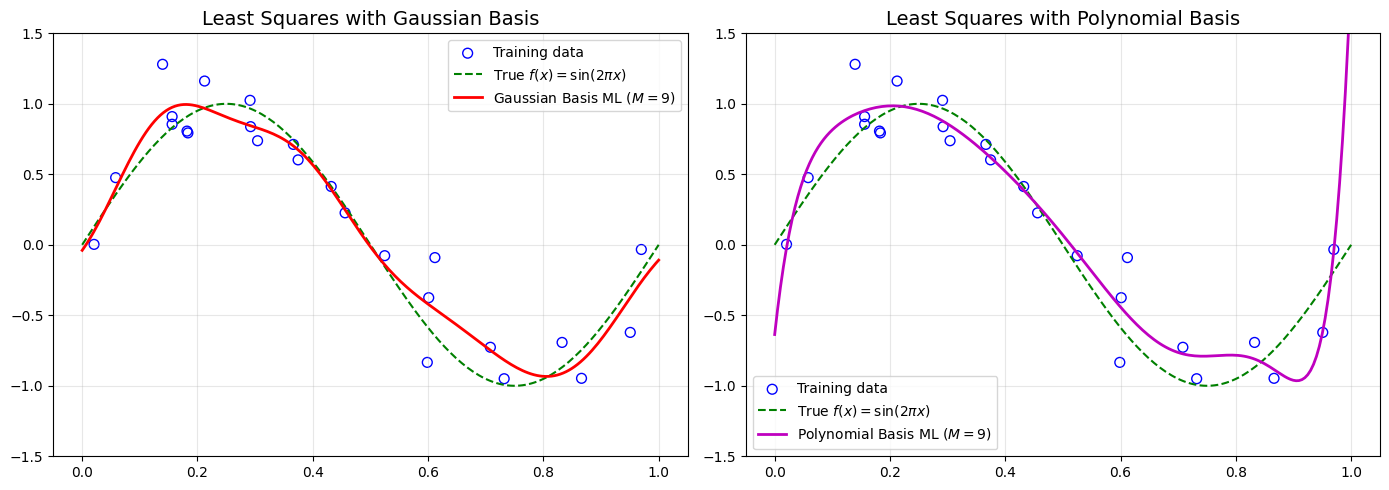

In [2]:
# 最尤推定フィッティングの実装と評価
from common.regression_utils import LinearRegression

np.random.seed(42)
N = 25
x_train = np.sort(np.random.uniform(0, 1, N))
# 真の関数: sin(2 * pi * x)
t_train = np.sin(2 * np.pi * x_train) + np.random.normal(0, 0.2, N)
x_dense = np.linspace(0, 1, 200)

# ガウス基底 (M=9)
centers_g = np.linspace(0, 1, 9)
gauss_basis = GaussianBasis(centers=centers_g, scale=0.1)
Phi_train_g = gauss_basis(x_train)
Phi_dense_g = gauss_basis(x_dense)

model_g = LinearRegression().fit(Phi_train_g, t_train)
y_pred_g = model_g.predict(Phi_dense_g)

# 多項式基底 (M=9)
poly_basis = PolynomialBasis(degree=9)
Phi_train_p = poly_basis(x_train)
Phi_dense_p = poly_basis(x_dense)
model_p = LinearRegression().fit(Phi_train_p, t_train)
y_pred_p = model_p.predict(Phi_dense_p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(x_train, t_train, facecolors='none', edgecolors='b', s=50, label='Training data')
axes[0].plot(x_dense, np.sin(2 * np.pi * x_dense), 'g--', label=r'True $f(x)=\sin(2\pi x)$')
axes[0].plot(x_dense, y_pred_g, 'r-', lw=2, label=r'Gaussian Basis ML ($M=9$)')
axes[0].set_ylim(-1.5, 1.5)
axes[0].set_title('Least Squares with Gaussian Basis')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(x_train, t_train, facecolors='none', edgecolors='b', s=50, label='Training data')
axes[1].plot(x_dense, np.sin(2 * np.pi * x_dense), 'g--', label=r'True $f(x)=\sin(2\pi x)$')
axes[1].plot(x_dense, y_pred_p, 'm-', lw=2, label=r'Polynomial Basis ML ($M=9$)')
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_title('Least Squares with Polynomial Basis')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig3_least_squares_fitting.png')
plt.show()

## 3.1.2 最小二乗法の幾何学的解釈 (Geometry of Least Squares)

最小二乗解は $N$ 次元データ空間における直交射影として美しい幾何学的意味を持ちます（PRML Figure 3.2）。

- 目標値ベクトル $\mathbf{t} = (t_1, \dots, t_N)^T$ は $N$ 次元空間の1つの点（ベクトル）です。
- モデルの予測値ベクトル $\mathbf{y} = \mathbf{\Phi} \mathbf{w} = \sum_{j=1}^M w_j \boldsymbol{\phi}_j$ は、基底ベクトル $\boldsymbol{\phi}_j \in \mathbb{R}^N$ の線形結合であり、$N$ 次元空間内の $M$ 次元部分空間 $\mathcal{S}$ に制限されます。
- 二乗和誤差 $\|\mathbf{t} - \mathbf{y}\|^2$ を最小化することは、**目標ベクトル $\mathbf{t}$ から部分空間 $\mathcal{S}$ までのユークリッド距離を最小にする点 $\mathbf{y}$ を見つけること**に他なりません。
- したがって、最尤解 $\mathbf{y}_{\mathrm{ML}} = \mathbf{\Phi} \mathbf{w}_{\mathrm{ML}} = \mathbf{\Phi} (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{t}$ は、$\mathbf{t}$ の部分空間 $\mathcal{S}$ への**直交射影 (Orthogonal Projection)** であり、射影行列 $\mathbf{P} = \mathbf{\Phi} (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T$ は $\mathbf{P}^2 = \mathbf{P}, \mathbf{P}^T = \mathbf{P}$ を満たします。
- 残差ベクトル $\mathbf{t} - \mathbf{y}_{\mathrm{ML}}$ は部分空間 $\mathcal{S}$（すべての列ベクトル $\boldsymbol{\phi}_j$）と直交します：
  $$ \mathbf{\Phi}^T (\mathbf{t} - \mathbf{y}_{\mathrm{ML}}) = \mathbf{\Phi}^T (\mathbf{t} - \mathbf{\Phi} (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{t}) = \mathbf{\Phi}^T \mathbf{t} - \mathbf{\Phi}^T \mathbf{t} = \mathbf{0} $$

Orthogonality check Phi^T @ (t - y): [0. 0.]
Plot saved to: result/fig3_2_orthogonal_projection_3d.png


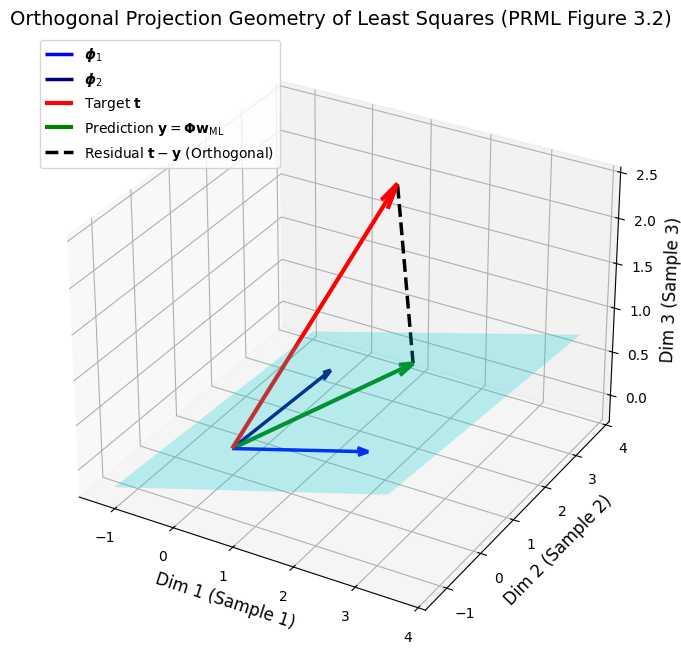

In [3]:
# 最小二乗直交射影の 3D 幾何学 (PRML Figure 3.2 の再現)
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(10)
# N = 3 次元のデータ空間, M = 2 次元の部分空間 S
phi1 = np.array([2.0, 0.5, 0.2])
phi2 = np.array([0.5, 2.0, 0.3])
Phi = np.column_stack([phi1, phi2]) # (3, 2)

# 目標ベクトル t
t = np.array([1.5, 2.2, 2.5])

# 直交射影 y = P @ t
P = Phi @ np.linalg.inv(Phi.T @ Phi) @ Phi.T
y = P @ t
residual = t - y

# 直交性の数値検証: Phi^T @ (t - y) == 0
orthogonality = Phi.T @ residual
print("Orthogonality check Phi^T @ (t - y):", np.round(orthogonality, 8))

# 3D プロット
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 部分空間 S の平面メッシュ
u_vals = np.linspace(-0.5, 1.5, 15)
v_vals = np.linspace(-0.5, 1.5, 15)
U, V = np.meshgrid(u_vals, v_vals)
Plane_X = U * phi1[0] + V * phi2[0]
Plane_Y = U * phi1[1] + V * phi2[1]
Plane_Z = U * phi1[2] + V * phi2[2]

ax.plot_surface(Plane_X, Plane_Y, Plane_Z, alpha=0.25, color='cyan', edgecolor='none')

# 基底ベクトル phi1, phi2
ax.quiver(0, 0, 0, phi1[0], phi1[1], phi1[2], color='blue', lw=2.5, arrow_length_ratio=0.08, label=r'$\boldsymbol{\phi}_1$')
ax.quiver(0, 0, 0, phi2[0], phi2[1], phi2[2], color='navy', lw=2.5, arrow_length_ratio=0.08, label=r'$\boldsymbol{\phi}_2$')

# 目標ベクトル t
ax.quiver(0, 0, 0, t[0], t[1], t[2], color='red', lw=3, arrow_length_ratio=0.08, label=r'Target $\mathbf{t}$')

# 射影ベクトル y
ax.quiver(0, 0, 0, y[0], y[1], y[2], color='green', lw=3, arrow_length_ratio=0.08, label=r'Prediction $\mathbf{y} = \mathbf{\Phi}\mathbf{w}_{\mathrm{ML}}$')

# 残差ベクトル (t - y)
ax.plot([y[0], t[0]], [y[1], t[1]], [y[2], t[2]], 'k--', lw=2.5, label=r'Residual $\mathbf{t} - \mathbf{y}$ (Orthogonal)')

ax.set_xlabel('Dim 1 (Sample 1)')
ax.set_ylabel('Dim 2 (Sample 2)')
ax.set_zlabel('Dim 3 (Sample 3)')
ax.set_title('Orthogonal Projection Geometry of Least Squares (PRML Figure 3.2)')
ax.legend(loc='upper left')

save_plot(fig, 'result', 'fig3_2_orthogonal_projection_3d.png')
plt.show()

## 3.1.3 逐次学習 (Sequential Learning / LMS Algorithm)

データが1点ずつ到着するオンライン学習環境や、データ数が膨大でバッチ逆行列計算 $(\mathbf{\Phi}^T \mathbf{\Phi})^{-1}$ が困難な場合は、確率的勾配降下法 (SGD) を用います。

単一データ点 $(\mathbf{x}_n, t_n)$ に対する二乗誤差 $E_n = \frac{1}{2} (t_n - \mathbf{w}^T \boldsymbol{\phi}_n)^2$ の勾配は
$$ \nabla E_n = - (t_n - \mathbf{w}^T \boldsymbol{\phi}_n) \boldsymbol{\phi}_n $$
したがって、重み更新式は
$$ \mathbf{w}^{(\tau+1)} = \mathbf{w}^{(\tau)} + \eta (t_n - {\mathbf{w}^{(\tau)}}^T \boldsymbol{\phi}_n) \boldsymbol{\phi}_n $$
これは Widrow-Hoff 法あるいは最小平均二乗法 (Least-Mean-Squares, LMS アルゴリズム) として広く知られています。

Plot saved to: result/fig3_lms_convergence.png


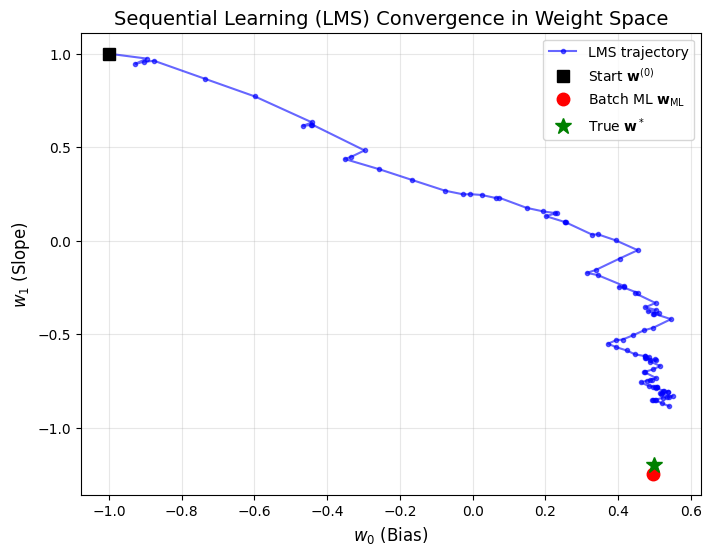

In [4]:
# LMS (逐次学習) のシミュレーションと最尤解への収束
np.random.seed(42)
N_pts = 100
x_seq = np.random.uniform(-1, 1, N_pts)
w_true = np.array([0.5, -1.2]) # バイアスと傾き
Phi_seq = np.column_stack([np.ones(N_pts), x_seq])
t_seq = Phi_seq @ w_true + np.random.normal(0, 0.2, N_pts)

# 最尤解 (バッチ)
w_ml = np.linalg.pinv(Phi_seq) @ t_seq

# LMS アルゴリズム
eta = 0.05
w_current = np.array([-1.0, 1.0]) # 初期重み
w_history = [w_current.copy()]

for n in range(N_pts):
    phi_n = Phi_seq[n]
    error = t_seq[n] - np.dot(w_current, phi_n)
    w_current = w_current + eta * error * phi_n
    w_history.append(w_current.copy())

w_history = np.array(w_history)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(w_history[:, 0], w_history[:, 1], 'b.-', alpha=0.6, label='LMS trajectory')
ax.plot(w_history[0, 0], w_history[0, 1], 'ks', markersize=8, label=r'Start $\mathbf{w}^{(0)}$')
ax.plot(w_ml[0], w_ml[1], 'ro', markersize=9, label=r'Batch ML $\mathbf{w}_{\mathrm{ML}}$')
ax.plot(w_true[0], w_true[1], 'g*', markersize=12, label=r'True $\mathbf{w}^*$')
ax.set_xlabel('$w_0$ (Bias)')
ax.set_ylabel('$w_1$ (Slope)')
ax.set_title('Sequential Learning (LMS) Convergence in Weight Space')
ax.legend()
ax.grid(True, alpha=0.3)

save_plot(fig, 'result', 'fig3_lms_convergence.png')
plt.show()

## 3.1.4 正則化最小二乗法：Ridge と Lasso の幾何学

過学習を抑制するため、誤差関数にペナルティ項（正則化項）を加えます。

$$ \tilde{E}(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^N \{t_n - \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n)\}^2 + \frac{\lambda}{2} \sum_{j=1}^M |w_j|^q $$

1. **L2 正則化 ($q=2$, Ridge / Weight Decay)**:
   $$ \mathbf{w}_{\mathrm{Ridge}} = (\lambda \mathbf{I} + \mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{t} $$
   係数が一様に小さくなりますが、厳密な 0 にはなりません。
2. **L1 正則化 ($q=1$, Lasso)**:
   多くの係数が厳密に 0 になる**スパース解 (Sparse Solution)** を導き、特徴選択の効果を持ちます。

### なぜ L1 正則化はスパース解を生むのか？ (PRML Figure 3.4 の幾何学)
制約付き最適化問題として捉えると、二乗誤差の等高線（楕円）が正則化制約領域 $\sum |w_j|^q \le C$ と最初に接触する点が最適解となります。
- **L2 制約面**: 球（円）であり、どの接点も滑らかであるため、座標軸上で接触する確率はほぼ 0 です。
- **L1 制約面**: 尖った角（特異点）を持つダイヤモンド（多面体）であり、等高線が**座標軸上の頂点（いくつかの重みが 0）で接触する確率が圧倒的に高くなります**。

Plot saved to: result/fig3_4_lasso_vs_ridge.png


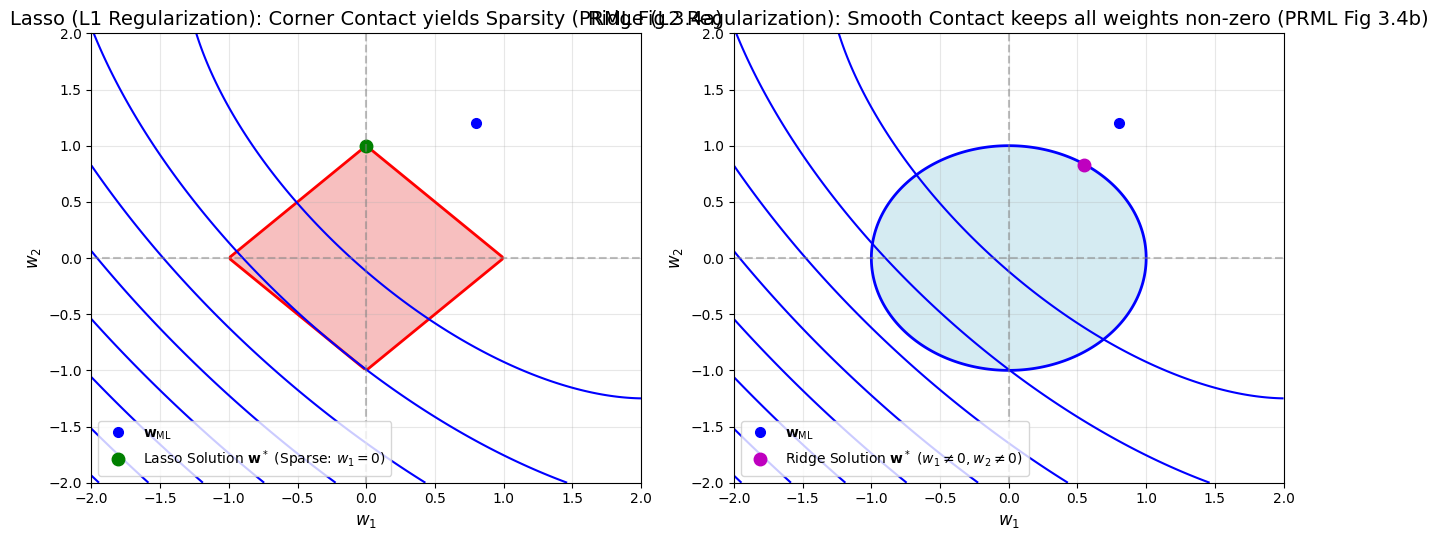

In [5]:
# PRML Figure 3.4 の再現: Lasso (L1) vs Ridge (L2) の幾何学的比較
w1 = np.linspace(-2, 2, 200)
w2 = np.linspace(-2, 2, 200)
W1, W2 = np.meshgrid(w1, w2)

# 最小二乗誤差の等高線 (中心 w_ml = [0.8, 1.2])
w_ml = np.array([0.8, 1.2])
H = np.array([[2.0, 1.0], [1.0, 1.5]]) # ヘッセ行列
E = 0.5 * (H[0,0]*(W1 - w_ml[0])**2 + 2*H[0,1]*(W1 - w_ml[0])*(W2 - w_ml[1]) + H[1,1]*(W2 - w_ml[1])**2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Lasso (L1): |w1| + |w2| <= 1.0
lasso_constraint = np.abs(W1) + np.abs(W2)
ax1.contourf(W1, W2, lasso_constraint, levels=[0, 1.0], colors=['lightcoral'], alpha=0.5)
ax1.contour(W1, W2, lasso_constraint, levels=[1.0], colors='red', linewidths=2)
ax1.contour(W1, W2, E, levels=8, colors='blue', linewidths=1.5)
ax1.plot(w_ml[0], w_ml[1], 'bo', markersize=7, label=r'$\mathbf{w}_{\mathrm{ML}}$')
ax1.plot(0.0, 1.0, 'go', markersize=9, label=r'Lasso Solution $\mathbf{w}^*$ (Sparse: $w_1=0$)')
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Lasso (L1 Regularization): Corner Contact yields Sparsity (PRML Fig 3.4a)')
ax1.set_xlabel('$w_1$')
ax1.set_ylabel('$w_2$')
ax1.legend(loc='lower left')
ax1.grid(True, alpha=0.3)

# Ridge (L2): w1^2 + w2^2 <= 1.0
ridge_constraint = W1**2 + W2**2
ax2.contourf(W1, W2, ridge_constraint, levels=[0, 1.0], colors=['lightblue'], alpha=0.5)
ax2.contour(W1, W2, ridge_constraint, levels=[1.0], colors='blue', linewidths=2)
ax2.contour(W1, W2, E, levels=8, colors='blue', linewidths=1.5)
ax2.plot(w_ml[0], w_ml[1], 'bo', markersize=7, label=r'$\mathbf{w}_{\mathrm{ML}}$')
ax2.plot(0.55, 0.83, 'mo', markersize=9, label=r'Ridge Solution $\mathbf{w}^*$ ($w_1 \neq 0, w_2 \neq 0$)')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Ridge (L2 Regularization): Smooth Contact keeps all weights non-zero (PRML Fig 3.4b)')
ax2.set_xlabel('$w_1$')
ax2.set_ylabel('$w_2$')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig3_4_lasso_vs_ridge.png')
plt.show()

## 3.1.5 複数出力の線形回帰 (Multiple Outputs)

目標変数がスカラー $t$ ではなく $K$ 次元のベクトル $\mathbf{t} \in \mathbb{R}^K$ である場合を考えます。
基底関数ベクトル $\boldsymbol{\phi}(\mathbf{x}) \in \mathbb{R}^M$ に対し、重み行列 $\mathbf{W} \in \mathbb{R}^{M \times K}$ を用いて
$$ \mathbf{y}(\mathbf{x}, \mathbf{W}) = \mathbf{W}^T \boldsymbol{\phi}(\mathbf{x}) $$
とモデル化します。
ノイズが等方的な場合 $p(\mathbf{t} | \mathbf{x}, \mathbf{W}, \beta) = \mathcal{N}(\mathbf{t} | \mathbf{W}^T \boldsymbol{\phi}(\mathbf{x}), \beta^{-1}\mathbf{I})$、対数尤度関数を最大化する解は
$$ \mathbf{W}_{\mathrm{ML}} = (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{T} $$
となり、各出力次元 $k$ ごとの重みベクトル $\mathbf{w}_k$ は互いに完全にデカップル（独立）して解くことができます。
一般的な共分散行列 $\mathbf{\Sigma}$ を持つ場合であっても、最尤推定解 $\mathbf{W}_{\mathrm{ML}}$ は全く同一となり、共分散行列の最尤推定量は
$$ \mathbf{\Sigma}_{\mathrm{ML}} = \frac{1}{N} \sum_{n=1}^N (\mathbf{t}_n - \mathbf{W}_{\mathrm{ML}}^T \boldsymbol{\phi}(\mathbf{x}_n))(\mathbf{t}_n - \mathbf{W}_{\mathrm{ML}}^T \boldsymbol{\phi}(\mathbf{x}_n))^T $$
となります（Exercise 3.6 参照）。

Plot saved to: result/fig3_multiple_outputs.png


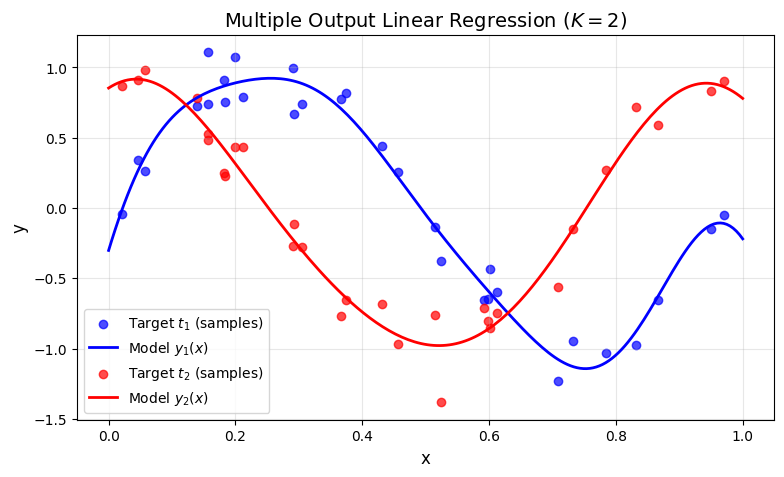

In [6]:
# 複数出力 (K=2) の回帰シミュレーション
from common.regression_utils import LinearRegression

np.random.seed(42)
N_samples = 30
x_multi = np.sort(np.random.uniform(0, 1, N_samples))
# 2つの出力: t1 = sin(2*pi*x), t2 = cos(2*pi*x)
T_multi = np.column_stack([
    np.sin(2 * np.pi * x_multi) + np.random.normal(0, 0.15, N_samples),
    np.cos(2 * np.pi * x_multi) + np.random.normal(0, 0.15, N_samples)
])

basis = GaussianBasis(centers=np.linspace(0, 1, 7), scale=0.15)
Phi_train_m = basis(x_multi)
Phi_dense_m = basis(x_dense)

# W_ML = pinv(Phi) @ T
W_ml = np.linalg.pinv(Phi_train_m) @ T_multi
Y_pred_m = Phi_dense_m @ W_ml

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x_multi, T_multi[:, 0], color='blue', alpha=0.7, label=r'Target $t_1$ (samples)')
ax.plot(x_dense, Y_pred_m[:, 0], 'b-', lw=2, label=r'Model $y_1(x)$')
ax.scatter(x_multi, T_multi[:, 1], color='red', alpha=0.7, label=r'Target $t_2$ (samples)')
ax.plot(x_dense, Y_pred_m[:, 1], 'r-', lw=2, label=r'Model $y_2(x)$')
ax.set_title('Multiple Output Linear Regression ($K=2$)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True, alpha=0.3)

save_plot(fig, 'result', 'fig3_multiple_outputs.png')
plt.show()